#Title: Big Data Analysis and Implementation for Enhancing Employee Well-being in organisations

##Table of Contents

Introduction

Methodology

*   Data Selection
*   Setup in Google Colab
*   Data Loading and Exploration

Analysis


*   Business Requirements Understanding
*   Data Extraction Techniques

Design


*   Data Quality Improvement Strategies
*   Ontology Generation

Implementation


*   Big Data Management with Dask
*   Cloud Computing Integration
*   Addressing Privacy and Trust

Results and Discussion

Conclusion

References

Appendices (if any)


##Introduction

**Brief Overview**

The project focuses on analyzing employee wellbeing using employee feedback data collected in a real organizational setting. Employee wellbeing is critical for fostering productivity, satisfaction, and retention within companies. The actual dataset, collected in May, 2025, includes structured and unstructured feedback from employees, such as satisfaction ratings, workload metrics, and open-ended textual responses.


**Business Problem**

The objective is to identify the factors contributing to employee dissatisfaction and recommend actionable strategies to improve workplace wellbeing. By understanding key drivers and patterns in the data, businesses can make informed/ data based decisions to enhance employee wellbeing.




**Objective**

The primary goals of this analysis are:

1.   Feature Identification - analyze the dataset to determine the most important features impacting employee well-being.
2.  Visualization - use tools like Matplotlib and Seaborn to explore relationships within the data, uncover trends, and highlight key insights.
3. Insight Generation - extract actionable insights from both structured and unstructured data to address areas of dissatisfaction.
4. Strategic Recommendations - propose evidence-based recommendations for improving workplace wellbeing based on analysis results.

These four objectives aim to support organizations in enchasing employee wellbeing and fostering a healthier and more productive work environment.

##Metadology

###Data Selection

*   Structured Data Source:
  * Format: .csv
  * Origin:
      * Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.
      
  * Attributes:
      * Employee ID (anonymized)
      * Department (anonymized)
      * Employee in department (numerical) - given by company
      * Date (date of fullfilment)
      * Time spent in company (categorical)
      * 15 questions with answers (categorical)
          * 3 questions have answer hierarcy (categorical)
          * 1 question - Wellbeing Score (10 point Likert scale)
      * Volume: 23.0 KB.

      * Purpose: Provides structured tabular data, ideal for statistical analysis, aggregation, and visualization. This dataset enables comprehensive insights into employee demographics, well-being, and satisfaction.



*   Unstructured/Semi-Structured Data Source:

  *   Format: .json
  *   Origin: Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.

  * Attributes:
      *   Employee ID (anonymized)
      *   Feedback Comments (unstructured text)

  * Volume: 70.5 KB.

  * Purpose: Facilitates hierarchical and relational analysis, particularly suited for Natural Language Processing (NLP) techniques and flexible querying. This data allows for deep insights into employee sentiment and textual feedback.

###Setup in Google Colab

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
!pip install rdflib
import dask.dataframe as dd
from cryptography.fernet import Fernet
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder for categorical features

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 25.5 MB/s eta 0:00:00


###Data Loading and Exploration

* **Structured Data**

In [3]:
# Loading structured data
structured_data = pd.read_csv('/content/structured_data.csv')

In [4]:
# Data frame dimension
structured_data.shape

(54, 36)

In [5]:
# Short view on data
structured_data.head()

,Respondent_ID,Nodaļa_Anonymized,Apmācības_vajadzības,Apmierinātība_ar_darba_laiku,Apmierinātība_ar_darba_slodzi,Apmierinātība_ar_informāciju,Dzimums,formid,Informācija_no_tiešā_vadītāja,Informācija_no_uzņēmuma_vadības,...,Stress_6,Stress_7,Tiešā_vadītāja_kompetence,Vēlamais_saziņas_veids_1,Vēlamais_saziņas_veids_2,Vēlamais_saziņas_veids_3,Vēlamais_saziņas_veids_4,Vēlamais_saziņas_veids_5,Vēlme_ieteikt_kompāniju,Vispārējās_labsajūtas_rādītājs
0,1,Nodaļa_1,Nē,Jā,Jā,Jā,Sieviete,form1027711226,Jā,Jā,...,NaN,NaN,Jā,"Telefoniski (sms, zvani)",Interneta vidē (e-pasts; sociālie tīkli vai pl...,Caur tiešo vadītāju,NaN,NaN,Ieteiktu,9
1,2,Nodaļa_3,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,Jā,Vīrietis,form1027711226,Jā,Jā,...,Nekas neizraisa,Nekas neizraisa,Jā,Caur tiešo vadītāju,Sapulces,"Telefoniski (sms, watsapp, zvani)",Interneta vidē (e-pasts; sociālie tīkli vai pl...,Informācija pie ziņojumu dēļiem (ja uzņēmumam ...,Ieteiktu,8
2,3,Nodaļa_1,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,"Cits: Ir brīži, kad trūkst nepieciešamā inform...",Sieviete,form1027711226,Jā,"Nē, jo informācija ir pārāk reti",...,NaN,NaN,Jā,Sapulces,Caur tiešo vadītāju,Interneta vidē (e-pasts; sociālie tīkli vai pl...,NaN,NaN,Ieteiktu,9
3,4,Nodaļa_7,"Jā, vēlos apgūt jaunas prasmes un pienākumus",Jā,Jā,Jā,Vīrietis,form1027711226,Jā,Jā,...,NaN,NaN,Jā,Interneta vidē (e-pasts; sociālie tīkli vai pl...,"Telefoniski (sms, Watsapp, zvani)",Caur tiešo vadītāju,NaN,NaN,Ieteiktu,9
4,5,Nodaļa_3,Cits,Cits,Cits,Cits,Vīrietis,form1027711226,Cits,"Nē, jo informācija ir pārāk reti",...,NaN,NaN,Cits,Cits,NaN,NaN,NaN,NaN,Ieteiktu,9


Unique values and counts in 'Dzimums' before replacement:
Dzimums
Vīrietis             41
Sieviete             10
Izvēlos nenorādīt     3
Name: count, dtype: int64
--------------------


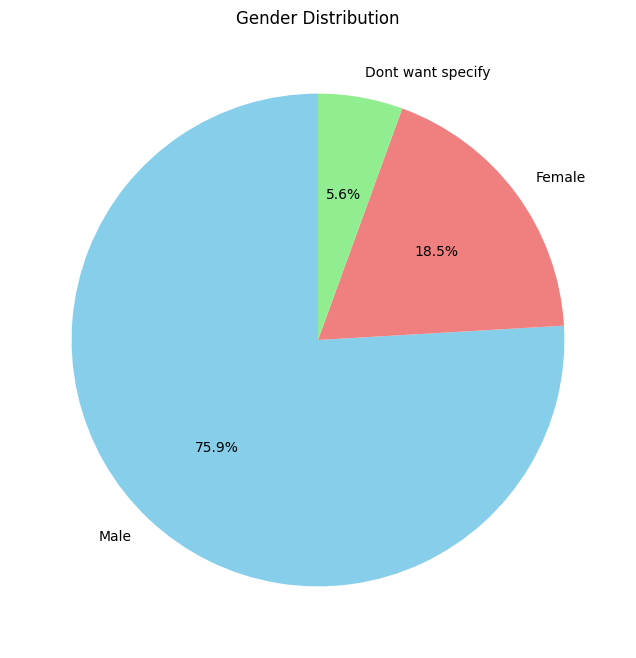

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Print unique values and their counts in the 'Dzimums' column BEFORE replacement
print("Unique values and counts in 'Dzimums' before replacement:")
print(structured_data['Dzimums'].value_counts(dropna=False))
print("-" * 20)

# Replace the labels for the pie chart
labels = ['Female', 'Male', 'Dont want specify']
# Ensure the values in the replace method exactly match the unique values in the column
structured_data['Dzimums'] = structured_data['Dzimums'].replace(['Sieviete', 'Vīrietis', 'Izvēlos nenorādīt'], labels)

# Count the occurrences of each gender *after* replacement
gender_counts = structured_data['Dzimums'].value_counts()

# Check if gender_counts is empty before attempting to plot
if not gender_counts.empty:
    # Update the labels to match the index of the gender_counts Series
    # This ensures the labels and data points align
    pie_labels = gender_counts.index.tolist()

    # Define a list of colors for the pie chart slices
    # Make sure the number of colors matches the number of slices (unique gender categories)
    colors = ['skyblue', 'lightcoral', 'lightgreen'] # Example colors

    # Create the pie chart with specified colors
    plt.figure(figsize=(8, 8))
    plt.pie(gender_counts, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title('Gender Distribution')
    plt.show()
else:
    print("No valid gender data found after replacement to create the pie chart.")
    print("Please check the values in the 'Dzimums' column in your structured data.")

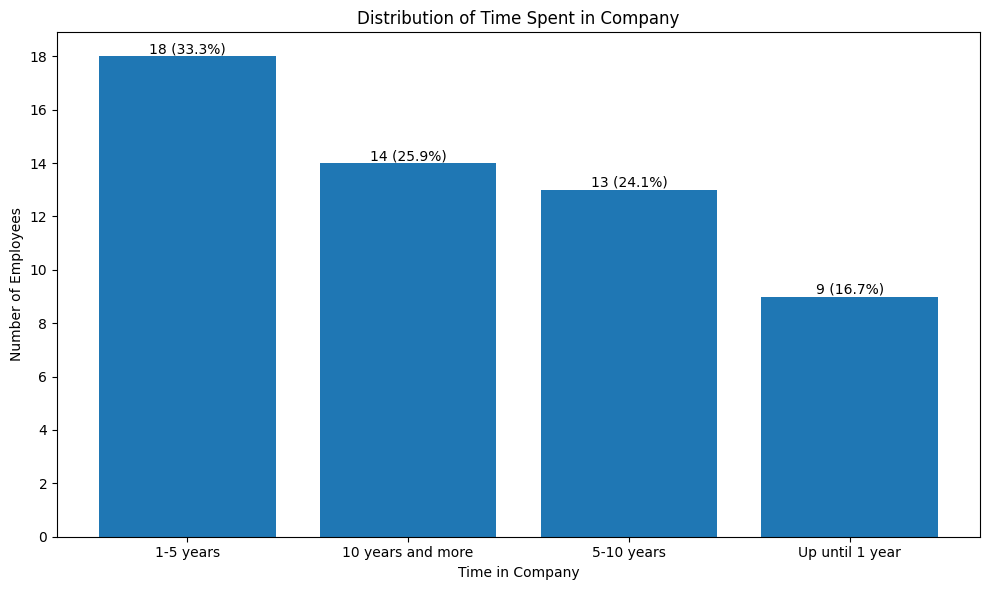

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter, MaxNLocator # Import MaxNLocator

# Correct the specific entry with incorrect spacing in the 'Laiks_uzņēmumā' column
# Replace '5 -10 gadi' with '5 - 10 gadi'
structured_data['Laiks_uzņēmumā'] = structured_data['Laiks_uzņēmumā'].replace('5 -10 gadi', '5 - 10 gadi')

# Count the occurrences of each time in company category after correction
# Use the column with correct spacing
time_in_company_counts = structured_data['Laiks_uzņēmumā'].value_counts().sort_index()

# Define the total number of answers
total_answers = 54

# Check if time_in_company_counts is empty before attempting to plot
if not time_in_company_counts.empty:
    # Define labels mapping from Latvian to English
    # Ensure these labels match the potentially corrected values in the column
    english_labels = {
        'Līdz 1 gadam': 'Up until 1 year',
        '1 - 5 gadi': '1-5 years',
        '5 - 10 gadi': '5-10 years',
        '10 gadi un vairāk': '10 years and more'
    }

    # Map Latvian labels to English labels for plotting
    # This should now work as the keys in english_labels match the corrected data
    labels_english = [english_labels[label] for label in time_in_company_counts.index]

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    # Use the default blue color by not specifying 'color'
    bars = plt.bar(labels_english, time_in_company_counts.values) # Store the bars object

    # Add labels on top of each bar as count and percentage
    for bar in bars:
        height = bar.get_height() # Get the height (count) of the bar
        percentage = (height / total_answers) * 100 # Calculate the percentage
        # Format the label as a string showing both count and percentage
        label_text = f'{int(height)} ({percentage:.1f}%)'
        plt.text(bar.get_x() + bar.get_width()/2, height, label_text, va='bottom', ha='center') # Add the label

    plt.title('Distribution of Time Spent in Company')
    plt.xlabel('Time in Company')
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=0) # Keep labels horizontal

    # Set y-axis ticks to be whole numbers
    ax = plt.gca() # Get the current axes
    ax.yaxis.set_major_locator(MaxNLocator(integer=True)) # Set major ticks to integers

    plt.tight_layout()
    plt.show()
else:
    print("No valid 'Laiks uzņēmumā' data found to create the bar plot.")
    print("Please check the values in the 'Laiks uzņēmumā' column in your structured data.")

In [9]:
# Check column data types and non-null values
print(structured_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Respondent_ID                    54 non-null     int64 
 1   Nodaļa_Anonymized                54 non-null     object
 2   Apmācības_vajadzības             54 non-null     object
 3   Apmierinātība_ar_darba_laiku     54 non-null     object
 4   Apmierinātība_ar_darba_slodzi    54 non-null     object
 5   Apmierinātība_ar_informāciju     54 non-null     object
 6   Dzimums                          54 non-null     object
 7   formid                           54 non-null     object
 8   Informācija_no_tiešā_vadītāja    54 non-null     object
 9   Informācija_no_uzņēmuma_vadības  54 non-null     object
 10  Izpratne_par_darba_pienākumiem   54 non-null     object
 11  Laiks_uzņēmumā                   54 non-null     object
 12  Novērtējums_1                    54 no

In [10]:
# Summary statistics for all numeric columns
print(structured_data.describe())

       Respondent_ID  Vispārējās_labsajūtas_rādītājs
count      54.000000                       54.000000
mean       27.500000                        8.074074
std        15.732133                        1.163142
min         1.000000                        6.000000
25%        14.250000                        7.000000
50%        27.500000                        8.000000
75%        40.750000                        9.000000
max        54.000000                       10.000000


In [11]:
# Count unique categories
print(structured_data[['Nodaļa_Anonymized', 'Dzimums', 'Laiks_uzņēmumā']].value_counts())

# Proportion of each category
print(structured_data[['Nodaļa_Anonymized', 'Dzimums', 'Laiks_uzņēmumā']].value_counts(normalize=True))

Nodaļa_Anonymized  Dzimums            Laiks_uzņēmumā   
Nodaļa_3           Male               1 - 5 gadi           8
Nodaļa_2           Male               10 gadi un vairāk    4
Nodaļa_3           Male               5 - 10 gadi          4
                                      Līdz 1 gadam         3
Nodaļa_4           Male               10 gadi un vairāk    3
                                      5 - 10 gadi          2
Nodaļa_5           Male               10 gadi un vairāk    2
Nodaļa_4           Male               1 - 5 gadi           2
Nodaļa_3           Male               10 gadi un vairāk    2
                   Female             1 - 5 gadi           2
Nodaļa_1           Female             5 - 10 gadi          2
Nodaļa_2           Male               5 - 10 gadi          2
Nodaļa_7           Male               5 - 10 gadi          2
Nodaļa_6           Male               1 - 5 gadi           2
Nodaļa_1           Female             Līdz 1 gadam         1
                   Male      

In [12]:
# prompt: I want to convert answer ' Nodaļa_Anonymized' from Latvian to english and name departments 'Department_1', 'Department_2' etc.for better presentation. How the best integrate this?

# Map Latvian department names to English and assign sequential numbers
department_mapping = {
    'Nodaļa_1': 'Department_1',
    'Nodaļa_2': 'Department_2',
    'Nodaļa_3': 'Department_3',
    'Nodaļa_4': 'Department_4',
    'Nodaļa_5': 'Department_5',
    'Nodaļa_6': 'Department_6',
    'Nodaļa_7': 'Department_7',
    'Izvēlos nenorādīt': 'Dont want specify',
        # Add more mappings as needed for other departments
}

structured_data['Department_Anonymized'] = structured_data['Nodaļa_Anonymized'].map(department_mapping)

# Now, 'Department_Anonymized' column contains the English department names.
# You can drop the original 'Nodaļa_Anonymized' column if you no longer need it.
# structured_data = structured_data.drop('Nodaļa_Anonymized', axis=1)

# You can verify the change
print(structured_data[['Nodaļa_Anonymized', 'Department_Anonymized']].value_counts())


Nodaļa_Anonymized  Department_Anonymized
Nodaļa_3           Department_3             21
Nodaļa_4           Department_4              9
Nodaļa_2           Department_2              7
Nodaļa_1           Department_1              7
Nodaļa_7           Department_7              4
Izvēlos nenorādīt  Dont want specify         2
Nodaļa_5           Department_5              2
Nodaļa_6           Department_6              2
Name: count, dtype: int64


In [13]:
# Summary statistics for specific columns
print(structured_data[['Nodaļa_Anonymized', 'Dzimums', 'Laiks_uzņēmumā']].describe())

       Nodaļa_Anonymized Dzimums Laiks_uzņēmumā
count                 54      54             54
unique                 8       3              4
top             Nodaļa_3    Male     1 - 5 gadi
freq                  21      41             18


In [14]:
# Analyze of data types (numerical, categorical, textual) and features like employee department, ratings, and feedback.

# 1. Understand the Dataset
print("Data Types and Feature Analysis:")

# Analyze data types
print("\nData Types:")
print(structured_data.dtypes)

# Analyze features
print("\nFeature Analysis:")

# Employee Department
print("\nEmployee Department:")
print(structured_data['Nodaļa_Anonymized'].value_counts()) # Frequency of each department
print(structured_data['Nodaļa_Anonymized'].unique())      # Unique departments


Data Types and Feature Analysis:

Data Types:
Respondent_ID                       int64
Nodaļa_Anonymized                  object
Apmācības_vajadzības               object
Apmierinātība_ar_darba_laiku       object
Apmierinātība_ar_darba_slodzi      object
Apmierinātība_ar_informāciju       object
Dzimums                            object
formid                             object
Informācija_no_tiešā_vadītāja      object
Informācija_no_uzņēmuma_vadības    object
Izpratne_par_darba_pienākumiem     object
Laiks_uzņēmumā                     object
Novērtējums_1                      object
Novērtējums_2                      object
Novērtējums_3                      object
Novērtējums_4                      object
Novērtējums_5                      object
Novērtējums_6                      object
Novērtējums_7                      object
Priekšlikumi_tiešajam_vadītājam    object
sent                               object
Stress_1                           object
Stress_2                      

In [15]:
# Count unique categories
print(structured_data['Laiks_uzņēmumā'].value_counts())

# Proportion of each category
print(structured_data['Laiks_uzņēmumā'].value_counts(normalize=True))

Laiks_uzņēmumā
1 - 5 gadi           18
10 gadi un vairāk    14
5 - 10 gadi          13
Līdz 1 gadam          9
Name: count, dtype: int64
Laiks_uzņēmumā
1 - 5 gadi           0.333333
10 gadi un vairāk    0.259259
5 - 10 gadi          0.240741
Līdz 1 gadam         0.166667
Name: proportion, dtype: float64


*   **Unstructured/Semi-structured Data**

In [17]:
# Loading unstructured data
unstructured_data = pd.read_json('/content/unstructured_data.json')

In [18]:
# Display the first few rows
print(unstructured_data.head())

   Respondent_ID                     Apmācības_vajadzības_Komentāri  \
0              1                                               None   
1              2                                               None   
2              3                                               None   
3              4                                               None   
4              5  Vēlētos apgūt darba optimizāciju, un izprast v...   

                              Darba_slodze_komentārs  \
0                                               None   
1                                               None   
2                                               None   
3                                               None   
4  Vairāk ne, jo vajag iet ārpus sava darba apjom...   

                              Darba_laiks__komentāri  \
0                                               None   
1                                               None   
2                                               None   
3           

In [19]:
# Check for null values
print(unstructured_data.isnull().sum())

Respondent_ID                                 0
Apmācības_vajadzības_Komentāri               50
Darba_slodze_komentārs                       44
Darba_laiks__komentāri                       49
Ieteikumi                                    20
Informācija_no_tiešā_vadītāja_Komentāri      49
Informācija_no_uzņēmuma_vadības_Komentāri    49
Izpratne_par_darba_pienākumiem_Komentāri     48
Nepieciešamā_informācija_Komentāri           47
Novērtējums_Komentāri                        50
Priekšlikumi_tiešajam_vadītājam_Komentāri    51
Saziņa_Komentāri                             49
Stress_Komentāri                             46
Tiešā_vadītāja_kompetence_Komentāri          49
Vēlme_darīt                                   0
Vēlme_ieteikt_kompāniju_Komentāri            48
Vispārējās_labsajūtas_rādītājs_Komentāri     50
dtype: int64


In [20]:
# Summary statistics for numerical columns
print(unstructured_data.describe())

       Respondent_ID
count      54.000000
mean       27.500000
std        15.732133
min         1.000000
25%        14.250000
50%        27.500000
75%        40.750000
max        54.000000


In [21]:
# Summary statistics for categorical columns
print(unstructured_data.describe(include=["object"]))

                           Apmācības_vajadzības_Komentāri  \
count                                                   4   
unique                                                  4   
top     Vēlētos apgūt darba optimizāciju, un izprast v...   
freq                                                    1   

                                   Darba_slodze_komentārs  \
count                                                  10   
unique                                                 10   
top     Vairāk ne, jo vajag iet ārpus sava darba apjom...   
freq                                                    1   

                                   Darba_laiks__komentāri Ieteikumi  \
count                                                   5        34   
unique                                                  5        34   
top     Un ja un ne, dažreiz var aiziet mājas laikus, ...      Nav.   
freq                                                    1         1   

       Informācija_no_tiešā_vadī

##Analysis

###Business Requirements Understanding

Problem: **"Identifying factors that contribute to employee dissatisfaction and predicting areas of improvement to enhance workplace wellbeing."**



###Data Extraction Techniques

To identify the most important features in project dataset author plans to make following steps:


1.  Understand the Dataset: Analyze data types (numerical, categorical, textual) and features like employee department, ratings, and feedback.

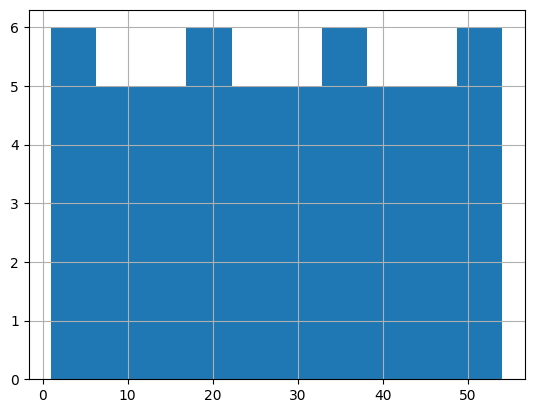

In [22]:
# Histogram for numeric data
structured_data['Respondent_ID'].hist()
plt.show()

Department_Anonymized
Department_1          7
Department_2          7
Department_3         21
Department_4          9
Department_5          2
Department_6          2
Department_7          4
Dont want specify     2
Name: Respondent_ID, dtype: int64


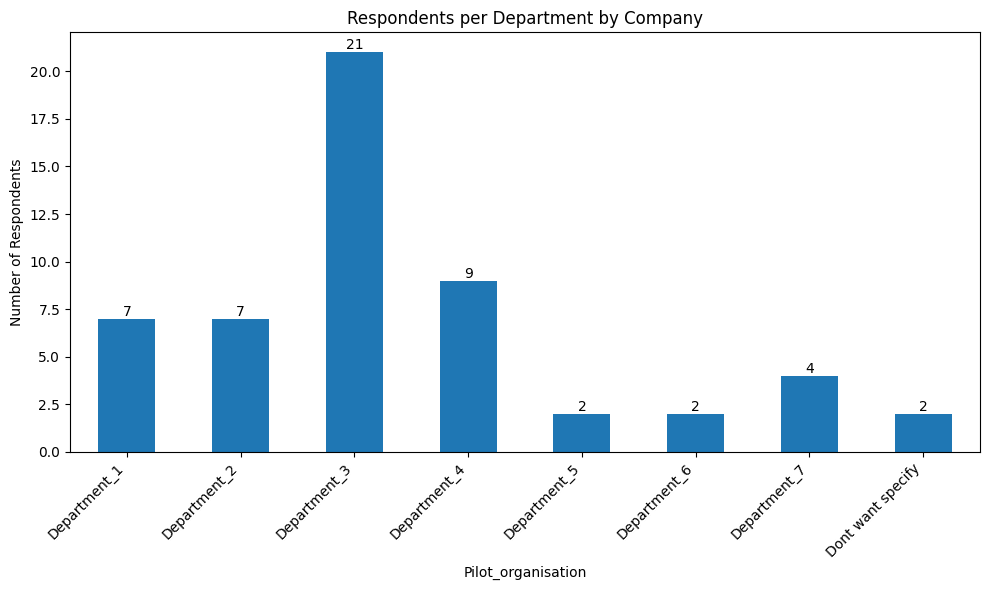

In [23]:
# Exploring respondents by departments for each company

# Group data by department, then count respondents
# Adapt to the FutureWarning by explicitly setting observed=False or True
respondent_counts_by_department = structured_data.groupby(['Department_Anonymized'], observed=False)['Respondent_ID'].nunique()

# Display the results (optional, but good for checking)
print(respondent_counts_by_department)

# Create the bar plot
ax = respondent_counts_by_department.plot(kind='bar', figsize=(10, 6)) # Assign the plot object to a variable 'ax'

plt.title('Respondents per Department by Company')
plt.xlabel('Pilot_organisation')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')

# Add the count of respondents above each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge') # Add labels above each bar

plt.tight_layout()
plt.show()

2.  Feature Selection
    *   Use statistical methods (e.g., correlation analysis, ANOVA).

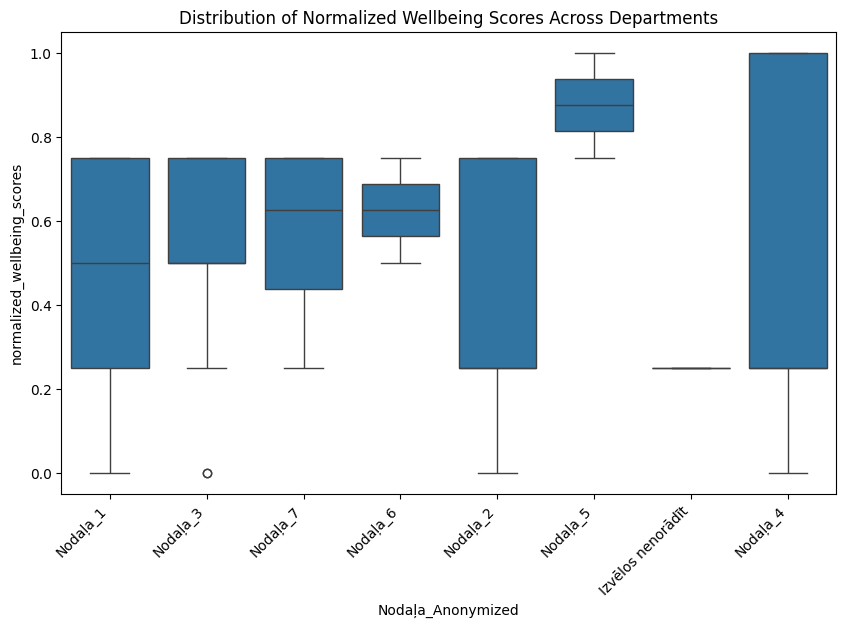

                                 OLS Regression Results                                
Dep. Variable:     normalized_wellbeing_scores   R-squared:                       0.116
Model:                                     OLS   Adj. R-squared:                 -0.019
Method:                          Least Squares   F-statistic:                    0.8606
Date:                         Mon, 26 May 2025   Prob (F-statistic):              0.544
Time:                                 18:08:24   Log-Likelihood:                -6.0961
No. Observations:                           54   AIC:                             28.19
Df Residuals:                               46   BIC:                             44.10
Df Model:                                    7                                         
Covariance Type:                     nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [25]:
# Improved Wellbeing Score Analysis
# Assuming the wellbeing scores are directly in the column 'Vispārējās_labsajūtas_rādītājs'
# Create a copy to avoid SettingWithCopyWarning on chained assignments
wellbeing_data_temp = structured_data.copy()

# Attempt to convert the relevant column to numeric
wellbeing_data_temp['Vispārējās_labsajūtas_rādītājs'] = pd.to_numeric(wellbeing_data_temp['Vispārējās_labsajūtas_rādītājs'], errors='coerce')

# Filter out rows where the wellbeing score is NaN
wellbeing_scores_valid = wellbeing_data_temp['Vispārējās_labsajūtas_rādītājs'].dropna()

# Ensure there are valid scores before proceeding
if not wellbeing_scores_valid.empty:
    # Normalization
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    # Reshape the data before scaling (MinMaxScaler expects a 2D array)
    wellbeing_scores_reshaped = wellbeing_scores_valid.values.reshape(-1, 1)
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores_reshaped)

    # Adding normalized scores back to the *original* structured_data DataFrame
    # Initialize the column with NaN first to ensure it exists
    structured_data['normalized_wellbeing_scores'] = np.nan
    # Assign the normalized values back using the index of the valid scores
    structured_data.loc[wellbeing_scores_valid.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    # --- Continue with the plotting and ANOVA code below ---
    # Analysis with normalized wellbeing scores
    # Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    # Filter structured_data to include only rows with valid normalized scores for plotting
    # Ensure 'Nodaļa_Anonymized' is also not NaN for plotting
    df_for_boxplot = structured_data.dropna(subset=['normalized_wellbeing_scores', 'Nodaļa_Anonymized'])
    # Check if df_for_boxplot is not empty and has enough unique departments before plotting
    if not df_for_boxplot.empty and len(df_for_boxplot['Nodaļa_Anonymized'].unique()) > 0:
        sns.boxplot(x='Nodaļa_Anonymized', y='normalized_wellbeing_scores', data=df_for_boxplot)
        plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
        plt.xticks(rotation=45, ha='right')
        plt.show()
    else:
        print("Not enough data with valid normalized wellbeing scores or unique departments to plot the boxplot.")


    # Example: ANOVA (Analysis of Variance)
    # Check if there's a significant difference in Wellbeing Score between departments
    import statsmodels.formula.api as sm

    # Ensure there is data for the ANOVA test after dropping NaNs
    df_for_anova = structured_data.dropna(subset=['normalized_wellbeing_scores', 'Nodaļa_Anonymized'])
    if not df_for_anova.empty:
        # Check if 'Nodaļa_Anonymized' column exists and has at least two distinct groups
        if 'Nodaļa_Anonymized' in df_for_anova.columns and len(df_for_anova['Nodaļa_Anonymized'].unique()) > 1:
            try:
                model = sm.ols('normalized_wellbeing_scores ~ C(Nodaļa_Anonymized)', data=df_for_anova).fit()
                print(model.summary())

                # Post-hoc analysis (Tukey's HSD) to identify which groups differ significantly
                from statsmodels.stats.multicomp import pairwise_tukeyhsd

                # Ensure there are at least two groups with data for Tukey test
                if len(df_for_anova['Nodaļa_Anonymized'].unique()) > 1:
                     m_comp = pairwise_tukeyhsd(endog=df_for_anova['normalized_wellbeing_scores'], groups=df_for_anova['Nodaļa_Anonymized'], alpha=0.05)
                     print(m_comp)
                else:
                    print("Not enough distinct departments with valid normalized wellbeing scores to perform Tukey's HSD test.")

            except Exception as e:
                print(f"An error occurred during ANOVA or Tukey test: {e}")
                print("Check if the 'Nodaļa_Anonymized' column contains sufficient data and variation for statistical tests.")
        else:
            print("The 'Nodaļa_Anonymized' column is missing or does not have enough distinct groups in the DataFrame used for ANOVA.")

    else:
        print("Not enough data with valid normalized wellbeing scores and departments to perform ANOVA.")
else:
    print("No valid numeric wellbeing scores found in the 'Vispārējās_labsajūtas_rādītājs' column after converting and dropping NaNs.")
    print("Cannot proceed with normalization and subsequent analyses.")

2.  Feature Selection
      * Apply feature importance techniques if building models (e.g., decision trees).

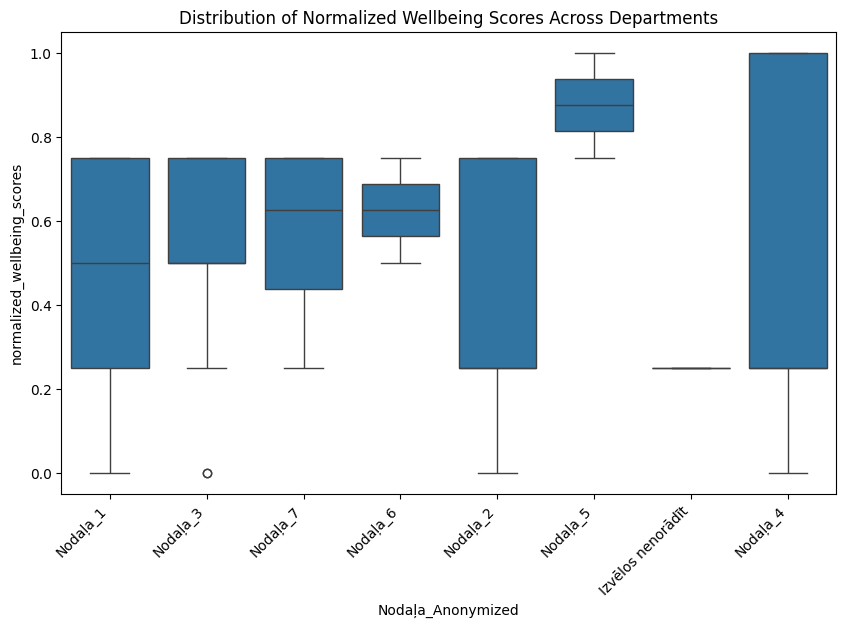

                                 OLS Regression Results                                
Dep. Variable:     normalized_wellbeing_scores   R-squared:                       0.116
Model:                                     OLS   Adj. R-squared:                 -0.019
Method:                          Least Squares   F-statistic:                    0.8606
Date:                         Mon, 26 May 2025   Prob (F-statistic):              0.544
Time:                                 18:10:00   Log-Likelihood:                -6.0961
No. Observations:                           54   AIC:                             28.19
Df Residuals:                               46   BIC:                             44.10
Df Model:                                    7                                         
Covariance Type:                     nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [26]:
# Improved Wellbeing Score Analysis
# Assuming the wellbeing scores are directly in the column 'Vispārējās_labsajūtas_rādītājs'
wellbeing_scores = structured_data['Vispārējās_labsajūtas_rādītājs']

# Convert wellbeing scores to numeric, handling errors
wellbeing_scores = pd.to_numeric(wellbeing_scores, errors='coerce')

# Remove rows with non-numeric values (e.g., 'No answer' if converted to NaN by coerce)
wellbeing_scores = wellbeing_scores.dropna()

# Ensure there are valid scores before proceeding
if not wellbeing_scores.empty:
    # Normalization
    scaler = MinMaxScaler()
    # Reshape the data before scaling (MinMaxScaler expects a 2D array)
    wellbeing_scores_reshaped = wellbeing_scores.values.reshape(-1, 1)
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores_reshaped)

    # Adding normalized scores back to the *original* structured_data DataFrame
    # Ensure index alignment by assigning back using the index of the non-null wellbeing_scores
    structured_data['normalized_wellbeing_scores'] = np.nan # Initialize the column
    structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    # Analysis with normalized wellbeing scores
    # Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    # Filter structured_data to include only rows with valid normalized scores for plotting
    df_for_boxplot = structured_data.dropna(subset=['normalized_wellbeing_scores'])
    # Check if df_for_boxplot is not empty before plotting
    if not df_for_boxplot.empty:
        # Check if the 'Nodaļa_Anonymized' column exists in the filtered dataframe before plotting
        if 'Nodaļa_Anonymized' in df_for_boxplot.columns:
            sns.boxplot(x='Nodaļa_Anonymized', y='normalized_wellbeing_scores', data=df_for_boxplot) # Use 'Nodaļa_Anonymized' for departmental analysis
            plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
            plt.xticks(rotation=45, ha='right')
            plt.show()
        else:
            print("The 'Nodaļa_Anonymized' column is missing from the DataFrame used for the boxplot.")
    else:
        print("Not enough data with valid normalized wellbeing scores to plot the boxplot.")


    # Example: ANOVA (Analysis of Variance)
    # Check if there's a significant difference in Wellbeing Score between departments
    import statsmodels.formula.api as sm

    # Ensure there is data for the ANOVA test after dropping NaNs
    df_for_anova = structured_data.dropna(subset=['normalized_wellbeing_scores'])
    if not df_for_anova.empty:
        # Check if 'Nodaļa_Anonymized' column exists in the filtered dataframe before running ANOVA
        if 'Nodaļa_Anonymized' in df_for_anova.columns:
            try:
                # Ensure there are at least two distinct groups in 'Nodaļa_Anonymized' for ANOVA
                if len(df_for_anova['Nodaļa_Anonymized'].unique()) > 1:
                    model = sm.ols('normalized_wellbeing_scores ~ C(Nodaļa_Anonymized)', data=df_for_anova).fit()
                    print(model.summary())

                    # Post-hoc analysis (Tukey's HSD) to identify which groups differ significantly
                    from statsmodels.stats.multicomp import pairwise_tukeyhsd

                    # Ensure there are at least two groups with data for Tukey test
                    if len(df_for_anova['Nodaļa_Anonymized'].unique()) > 1:
                         m_comp = pairwise_tukeyhsd(endog=df_for_anova['normalized_wellbeing_scores'], groups=df_for_anova['Nodaļa_Anonymized'], alpha=0.05)
                         print(m_comp)
                    else:
                        print("Not enough distinct departments with valid normalized wellbeing scores to perform Tukey's HSD test.")

                else:
                     print("Not enough distinct departments with valid normalized wellbeing scores to perform ANOVA.")

            except Exception as e:
                print(f"An error occurred during ANOVA or Tukey test: {e}")
                print("Check if the 'Nodaļa_Anonymized' column contains sufficient data and variation for statistical tests.")
        else:
            print("The 'Nodaļa_Anonymized' column is missing from the DataFrame used for ANOVA.")

    else:
        print("Not enough data with valid normalized wellbeing scores to perform ANOVA.")
else:
    print("No valid numeric wellbeing scores found in the 'Vispārējās_labsajūtas_rādītājs' column after converting and dropping NaNs.")

In [27]:
# Import necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder for categorical features

# Prepare data
X = structured_data.drop(['Nodaļa_Anonymized', 'normalized_wellbeing_scores'], axis=1)  # Features, remove target variable
y = structured_data['normalized_wellbeing_scores']  # Target variable

# Convert categorical features to numerical using OneHotEncoding
# Identify categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create OneHotEncoder object with sparse=False and handle_unknown='ignore'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical features using the original X DataFrame
# This ensures that the encoded features have the same number of rows as the original data
encoded_features = encoder.fit_transform(X[categorical_features])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features), index=X.index) # Added index to align with X

# Replace original categorical features with encoded features
X = X.drop(categorical_features, axis=1)
X = pd.concat([X, encoded_df], axis=1)

# Now proceed with train-test split and model fitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Example using RandomForestClassifier (Decision Tree based)
model = RandomForestClassifier(n_estimators=100, random_state=42) # adjust parameters
model.fit(X_train, y_train)

# Feature importance from the model itself
importances = model.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names)

# Permutation Feature Importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
forest_importances_permutation = pd.Series(result.importances_mean, index=feature_names)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

#Plot permutation feature importance
fig, ax = plt.subplots(figsize=(10,6))
forest_importances_permutation.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

3. Visual Exploration

    *   Use heatmaps to identify correlations between numerical features.
    *   Plot bar charts for categorical distributions (e.g., employee roles).
    *   Use word clouds to visualize common themes in textual feedback.

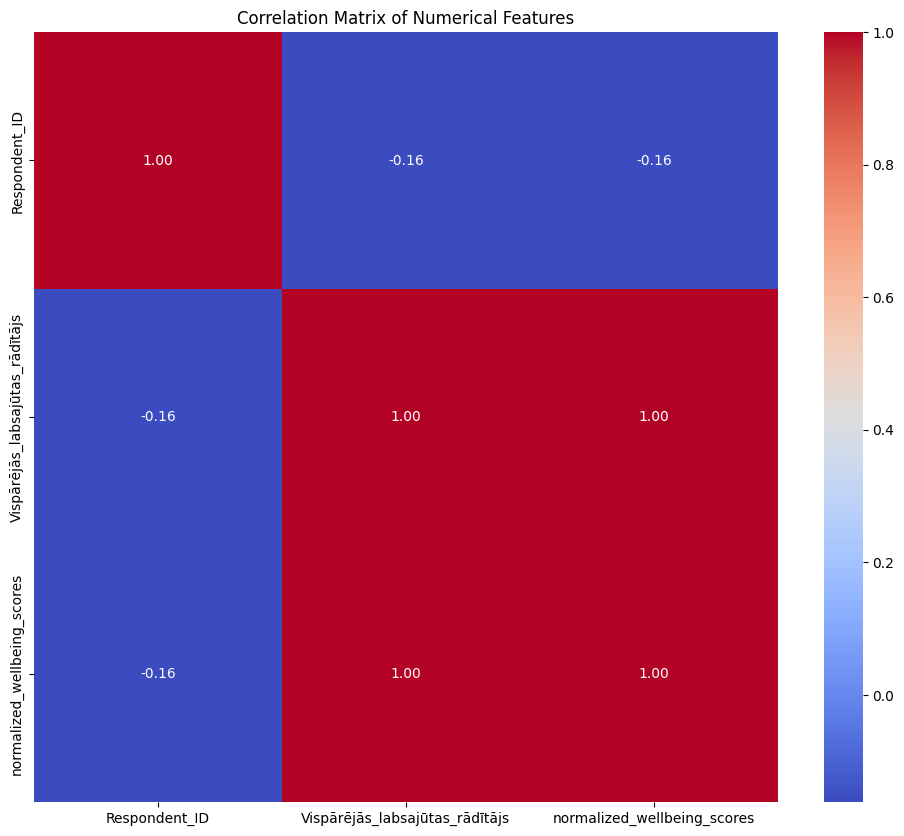

In [28]:
# Use of heatmaps to identify correlations between numerical features.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features for correlation analysis
numerical_features = structured_data.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

4. Insights - focus on features with significant patterns, high correlations, or strong impact on the target variable.

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(structured_data['Employee in department'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(structured_data, x='Respondent ID', y='Employee in department', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

KeyError: 'Employee in department'

KeyError: 'Department'

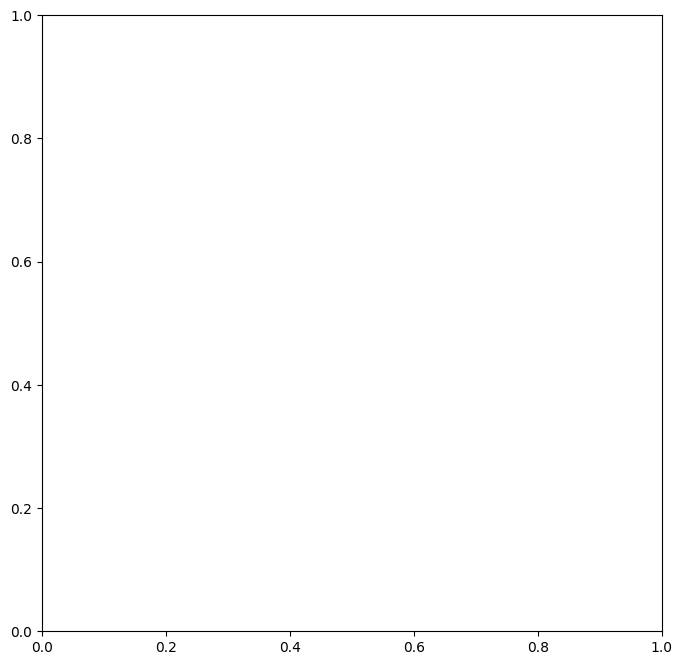

In [30]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Employee in department'].value_counts()
    for x_label, grp in structured_data.groupby('Department')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Department')
_ = plt.ylabel('Employee in department')

In [1]:
# Feedback (Textual data from unstructured dataset)
print("\nFeedback (Textual Data):")
print(unstructured_data.head()) # Show the first few rows of the unstructured data
print(unstructured_data['Ieteikumi'].describe()) # Summary stats of the feedback column
# Analyze the length of feedback comments
unstructured_data['comment_length'] = unstructured_data['Ieteikumi'].astype(str).apply(len)
print(unstructured_data['comment_length'].describe())
unstructured_data['comment_length'].hist()
plt.title('Distribution of Feedback Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()


Feedback (Textual Data):


NameError: name 'unstructured_data' is not defined

In [33]:
# Explore relationship between department and wellbeing score

# 'Wellbeing Score' is the column to analyze
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

# Add the 'wellbeing_scores' as a column to the structured_data DataFrame
structured_data['wellbeing_scores'] = pd.to_numeric(wellbeing_data['Answer'], errors='coerce')

#Now you can use the 'wellbeing_scores' column for the boxplot:
sns.boxplot(x='Department', y='wellbeing_scores', data=structured_data)
plt.xticks(rotation=45, ha='right')
plt.title('Wellbeing Score Distribution Across Departments')
plt.show()

KeyError: 'Question'

In [34]:
# Improved Wellbeing Score Analysis
wellbeing_data = structured_data['Vispārējās_labsajūtas_rādītājs']

if not wellbeing_data.empty:
    wellbeing_scores = pd.to_numeric(wellbeing_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')
    wellbeing_scores = wellbeing_scores.dropna()

    # Normalization
    scaler = MinMaxScaler()
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores.values.reshape(-1, 1))

    # Adding normalized scores back to the DataFrame
    structured_data['normalized_wellbeing_scores'] = np.nan
    # Index alignment for assignment
    structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    #Analysis with normalized wellbeing scores
    #Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Nodaļa_Anonymized', y='normalized_wellbeing_scores', data=structured_data)
    plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("No data found for the wellbeing question")
    wellbeing_scores = pd.to_numeric(wellbeing_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')
    wellbeing_scores = wellbeing_scores.dropna()

    # Normalization
    scaler = MinMaxScaler()
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores.values.reshape(-1, 1))

    # Adding normalized scores back to the DataFrame
    structured_data['normalized_wellbeing_scores'] = np.nan
    # Index alignment for assignment
    structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    #Analysis with normalized wellbeing scores
    #Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Nodaļa_Anonymized', y='normalized_wellbeing_scores', data=structured_data)
    plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
# Improved Wellbeing Score Analysis
wellbeing_data = structured_data[structured_data['Vispārējās_labsajūtas_rādītājs'].notna()]

if not wellbeing_data.empty:
    wellbeing_scores = pd.to_numeric(wellbeing_data['Vispārējās_labsajūtas_rādītājs'], errors='coerce')
    wellbeing_scores = wellbeing_scores.dropna()

    # Normalization
    scaler = MinMaxScaler()
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores.values.reshape(-1, 1))

    # Adding normalized scores back to the DataFrame
    structured_data['normalized_wellbeing_scores'] = np.nan
    # Index alignment for assignment
    structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    #Analysis with normalized wellbeing scores
    #Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Nodaļa_Anonymized', y='normalized_wellbeing_scores', data=structured_data)
    plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("No data found for the wellbeing question")

KeyError: 'Vispārējās_labsajūtas_rādītājs'

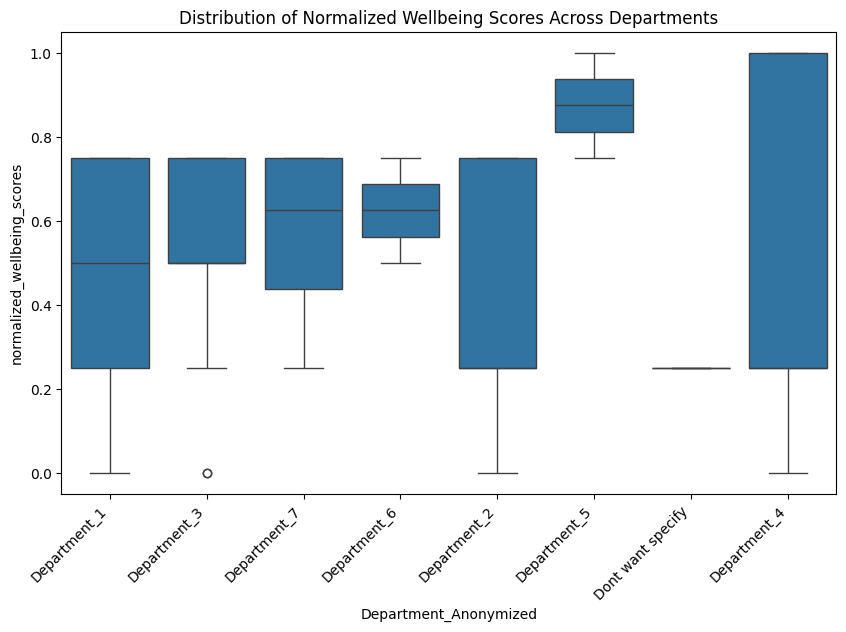

In [31]:
# Improved Wellbeing Score Analysis
# wellbeing_data is already the Series containing the 'Vispārējās_labsajūtas_rādītājs' column
wellbeing_data = structured_data['Vispārējās_labsajūtas_rādītājs']

if not wellbeing_data.empty:
    # Apply pd.to_numeric directly to the wellbeing_data Series
    wellbeing_scores = pd.to_numeric(wellbeing_data, errors='coerce')
    wellbeing_scores = wellbeing_scores.dropna()

    # Ensure there are valid scores after dropping NaNs before proceeding
    if not wellbeing_scores.empty:
        # Normalization
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        # Reshape the data before scaling (MinMaxScaler expects a 2D array)
        wellbeing_scores_reshaped = wellbeing_scores.values.reshape(-1, 1)
        normalized_wellbeing = scaler.fit_transform(wellbeing_scores_reshaped)

        # Adding normalized scores back to the *original* structured_data DataFrame
        # Ensure index alignment by assigning back using the index of the non-null wellbeing_scores
        # Initialize the column with NaN first to avoid SettingWithCopyWarning
        structured_data['normalized_wellbeing_scores'] = np.nan
        structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

        # Analysis with normalized wellbeing scores
        # Example: Boxplot of normalized wellbeing score distribution across Departments
        plt.figure(figsize=(10, 6))
        # Filter structured_data to include only rows with valid normalized scores for plotting
        df_for_boxplot = structured_data.dropna(subset=['normalized_wellbeing_scores', 'Nodaļa_Anonymized'])
        # Check if df_for_boxplot is not empty and has enough unique departments before plotting
        if not df_for_boxplot.empty and len(df_for_boxplot['Department_Anonymized'].unique()) > 0:
            sns.boxplot(x='Department_Anonymized', y='normalized_wellbeing_scores', data=df_for_boxplot) # Use 'Nodaļa_Anonymized' for departmental analysis
            plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
            plt.xticks(rotation=45, ha='right')
            plt.show()
        else:
            print("Not enough data with valid normalized wellbeing scores or unique departments to plot the boxplot.")

    else:
         print("No valid numeric wellbeing scores found after dropping non-numeric entries.")
else:
    print("The 'Vispārējās_labsajūtas_rādītājs' column in structured_data is empty.")

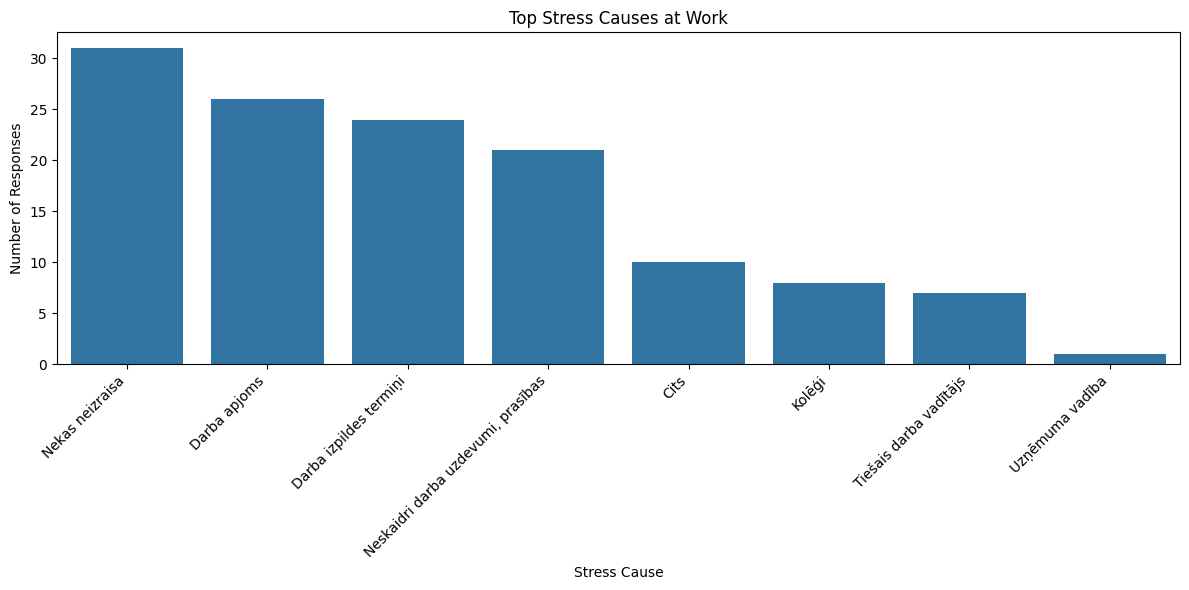

In [45]:
# From structured_data columns 'Stress_1', 'Stress_2', 'Stress_3','Stress_4', 'Stress_5', 'Stress_6', 'Stress_7'
# Collect stress causes and offer suitable visual presentation showing categories, clean 'No answers'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Assuming 'structured_data' is your DataFrame

# List of columns containing stress causes
stress_cause_columns = ['Stress_1', 'Stress_2', 'Stress_3', 'Stress_4', 'Stress_5', 'Stress_6', 'Stress_7']

all_stress_causes = []

# Check if all stress columns exist in the DataFrame
if all(col in structured_data.columns for col in stress_cause_columns):
    # Iterate through each row of the DataFrame
    for index, row in structured_data.iterrows():
        # For each row, collect values from the stress cause columns
        for col in stress_cause_columns:
            cause = row[col]
            # Add the cause to the list if it's not null/NaN
            if pd.notna(cause):
                all_stress_causes.append(cause)

    # Clean 'No answers' - case insensitive and strip whitespace
    all_stress_causes = [cause for cause in all_stress_causes if isinstance(cause, str) and cause.lower().strip() != 'no answer']

    # Count the frequency of each stress cause
    cause_counts = Counter(all_stress_causes)

    # Check if there are any stress causes to visualize
    if cause_counts:
        # Create a DataFrame for better visualization
        df_stress_causes = pd.DataFrame.from_dict(cause_counts, orient='index', columns=['Count'])
        df_stress_causes.index.name = 'Stress Cause'
        df_stress_causes = df_stress_causes.sort_values('Count', ascending=False) # Sort by frequency

        # Visualize the top N stress causes using a bar plot
        N = 10 # Number of top causes to display
        plt.figure(figsize=(12,6))
        # Select top N causes for plotting, handle cases where there are less than N unique causes
        top_n_stress_causes = df_stress_causes.head(N)
        sns.barplot(x=top_n_stress_causes.index, y=top_n_stress_causes['Count'])
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
        plt.title('Top Stress Causes at Work')
        plt.xlabel('Stress Cause')
        plt.ylabel('Number of Responses')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid stress causes found to visualize after cleaning.")

else:
    print("One or more of the specified stress cause columns ('Stress_1' to 'Stress_7') do not exist in the DataFrame.")
    print("Please check the column names in your 'structured_data' DataFrame.")

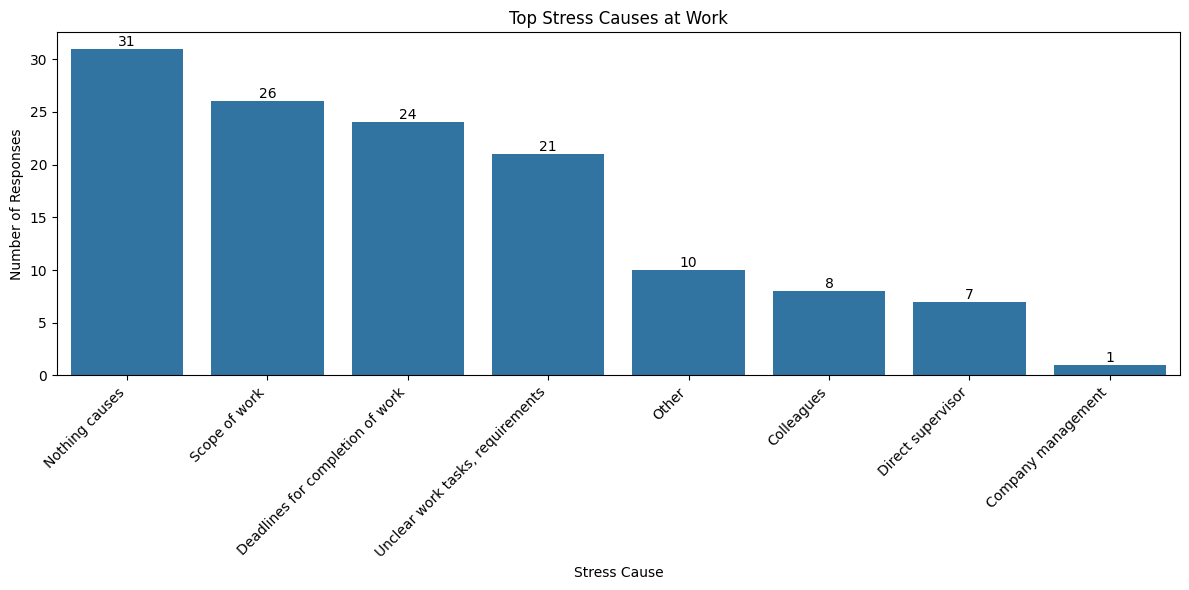

In [45]:
# From structured_data columns 'Stress_1', 'Stress_2', 'Stress_3','Stress_4', 'Stress_5', 'Stress_6', 'Stress_7'
# Collect stress causes and offer suitable visual presentation showing categories, clean 'No answers'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Assuming 'structured_data' is your DataFrame

# List of columns containing stress causes
stress_cause_columns = ['Stress_1', 'Stress_2', 'Stress_3', 'Stress_4', 'Stress_5', 'Stress_6', 'Stress_7']

all_stress_causes = []

# Check if all stress columns exist in the DataFrame
if all(col in structured_data.columns for col in stress_cause_columns):
    # Iterate through each row of the DataFrame
    for index, row in structured_data.iterrows():
        # For each row, collect values from the stress cause columns
        for col in stress_cause_columns:
            cause = row[col]
            # Add the cause to the list if it's not null/NaN
            if pd.notna(cause):
                all_stress_causes.append(cause)

    # Clean 'No answers' - case insensitive and strip whitespace
    all_stress_causes = [cause for cause in all_stress_causes if isinstance(cause, str) and cause.lower().strip() != 'no answer']

    # Define the mapping for Latvian to English labels
    english_stress_labels = {
        'Nekas neizraisa': 'Nothing causes',
        'Darba apjoms': 'Scope of work',
        'Darba izpildes termiņi': 'Deadlines for completion of work',
        'Neskaidri darba uzdevumi, prasības': 'Unclear work tasks, requirements',
        'Cits': 'Other',
        'Kolēģi': 'Colleagues',
        'Tiešais darba vadītājs': 'Direct supervisor',
        'Uzņēmuma vadība': 'Company management'
    }

    # Map the collected stress causes to English labels
    english_stress_causes = [english_stress_labels.get(cause, cause) for cause in all_stress_causes]

    # Count the frequency of each stress cause (using English labels)
    cause_counts = Counter(english_stress_causes)

    # Check if there are any stress causes to visualize
    if cause_counts:
        # Create a DataFrame for better visualization
        df_stress_causes = pd.DataFrame.from_dict(cause_counts, orient='index', columns=['Count'])
        df_stress_causes.index.name = 'Stress Cause'
        df_stress_causes = df_stress_causes.sort_values('Count', ascending=False) # Sort by frequency

        # Visualize the top N stress causes using a bar plot
        N = 10 # Number of top causes to display
        plt.figure(figsize=(12,6))
        # Select top N causes for plotting, handle cases where there are less than N unique causes
        top_n_stress_causes = df_stress_causes.head(N)
        bars = sns.barplot(x=top_n_stress_causes.index, y=top_n_stress_causes['Count']) # Store the bars object

        # Add labels on top of each bar
        for bar in bars.patches:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center') # Add the count as integer

        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
        plt.title('Top Stress Causes at Work')
        plt.xlabel('Stress Cause')
        plt.ylabel('Number of Responses')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid stress causes found to visualize after cleaning and mapping.")

else:
    print("One or more of the specified stress cause columns ('Stress_1' to 'Stress_7') do not exist in the DataFrame.")
    print("Please check the column names in your 'structured_data' DataFrame.")

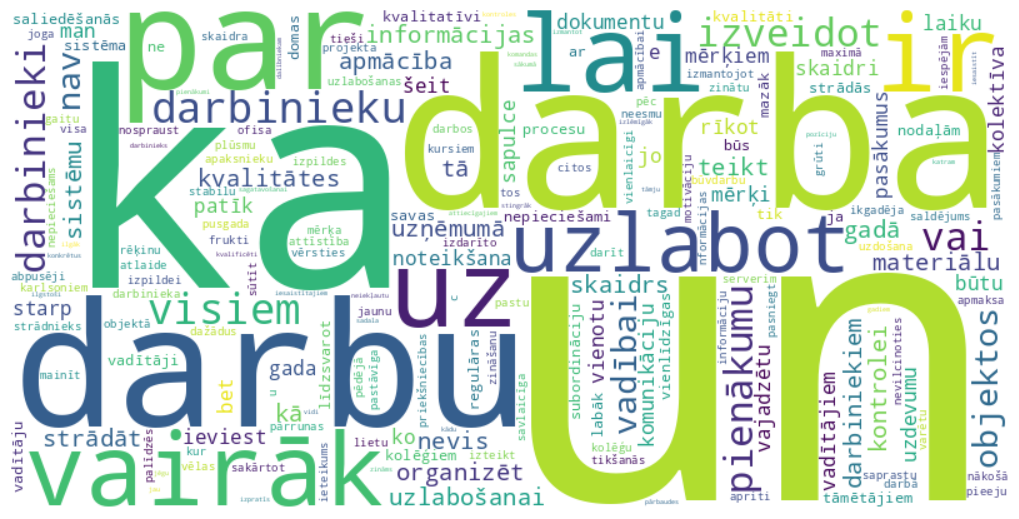

In [38]:
# Visual representation of unstructured dataset filtering by
# Recommendations for improving the organization of the work process
# Load data
unstructured_data = pd.read_json('/content/unstructured_data.json')

#Lower case all text in 'Ieteikumi' column
unstructured_data['Ieteikumi'] = unstructured_data['Ieteikumi'].str.lower() # make lowercase

# Filter out rows where 'Ieteikumi' is empty or 'No answer' (assuming 'No answer' is a possible value in this column)
# We'll also handle potential NaN values.
filtered_data = unstructured_data[unstructured_data['Ieteikumi'].notna() & (unstructured_data['Ieteikumi'] != 'no answer')]

# The previous filtering by 'Question' might not be necessary if 'Ieteikumi' column
# directly contains the recommendation text. However, if 'Ieteikumi' is a response to a specific
# question within the unstructured data, you might need to filter by 'Question' as before.
# Assuming 'Ieteikumi' stands alone as the recommendations text, we proceed without filtering by 'Question'.
# If 'Ieteikumi' is tied to a specific question, you would reintroduce the question filtering.

# Create your visual representation.  A word cloud is a good choice for this kind of data.
from wordcloud import WordCloud

# Combine all text responses from 'Ieteikumi' into a single string
text = ' '.join(filtered_data['Ieteikumi'].astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the generated image:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

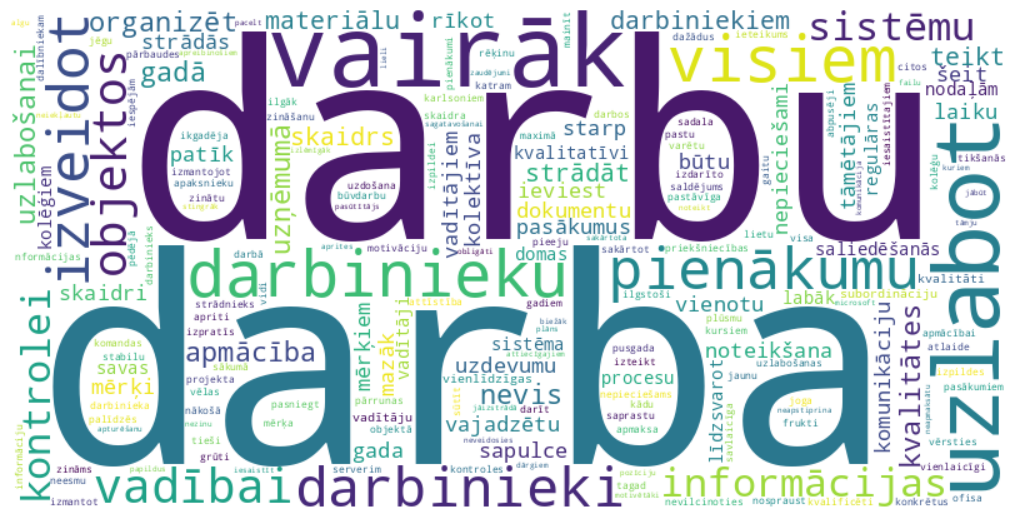

In [39]:
# Visual representation of unstructured dataset filtering by
# Recommendations for improving the organization of the work process
# Load data
unstructured_data = pd.read_json('/content/unstructured_data.json')

#Lower case all text in 'Ieteikumi' column
unstructured_data['Ieteikumi'] = unstructured_data['Ieteikumi'].str.lower() # make lowercase

# Filter out rows where 'Ieteikumi' is empty or 'No answer' (assuming 'No answer' is a possible value in this column)
# We'll also handle potential NaN values.
filtered_data = unstructured_data[unstructured_data['Ieteikumi'].notna() & (unstructured_data['Ieteikumi'] != 'no answer')]

# Create your visual representation.  A word cloud is a good choice for this kind of data.
from wordcloud import WordCloud
import re # Import the regular expression module for splitting words

# Combine all text responses from 'Ieteikumi' into a single string
text = ' '.join(filtered_data['Ieteikumi'].astype(str))

# Split the text into words and filter out words shorter than 4 characters
words = re.findall(r'\b\w{4,}\b', text) # Use regex to find words with 4 or more characters
filtered_text = ' '.join(words) # Join the filtered words back into a string

# Generate the word cloud using the filtered text
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)

# Display the generated image:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

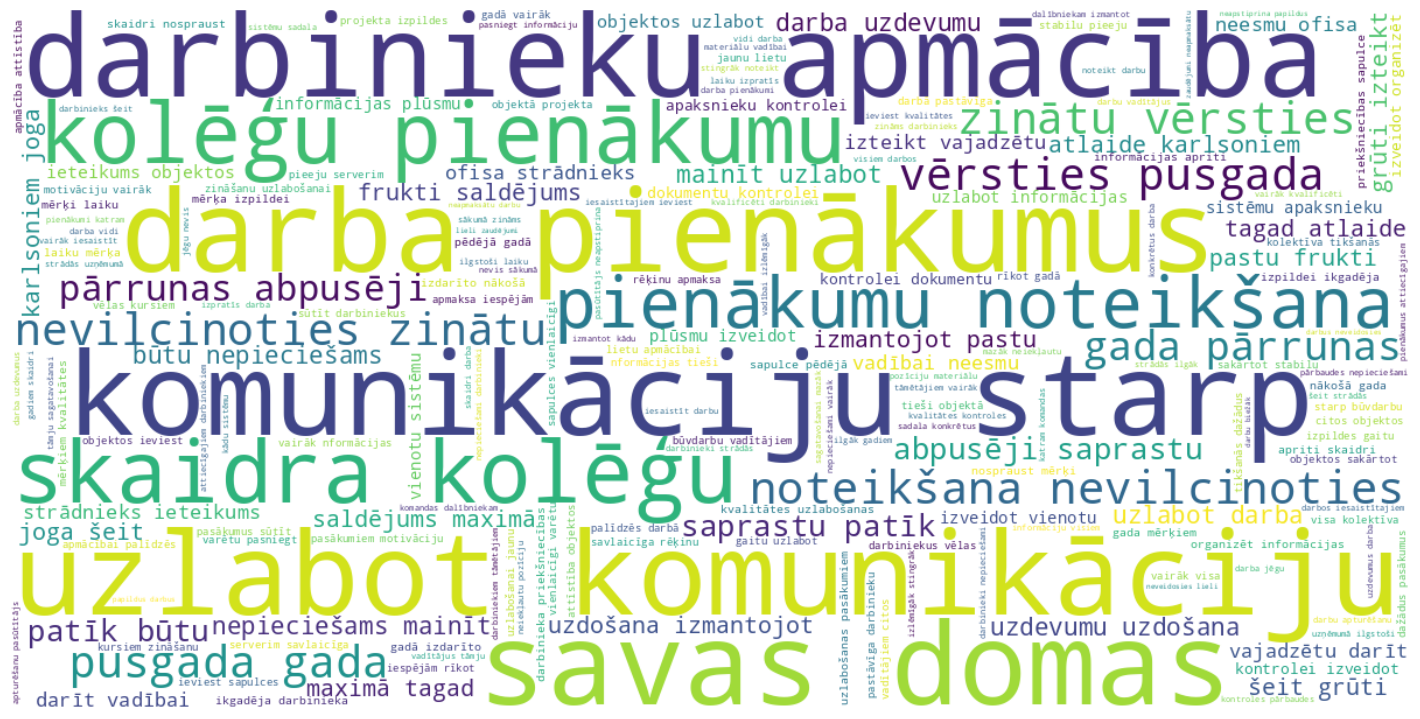

In [40]:
# Visual representation of unstructured dataset filtering by
# Recommendations for improving the organization of the work process - Bigrams
# Load data
unstructured_data = pd.read_json('/content/unstructured_data.json')

# Lower case all text in 'Ieteikumi' column
unstructured_data['Ieteikumi'] = unstructured_data['Ieteikumi'].str.lower()

# Filter out rows where 'Ieteikumi' is empty or 'No answer'
filtered_data = unstructured_data[unstructured_data['Ieteikumi'].notna() & (unstructured_data['Ieteikumi'] != 'no answer')]

import re
from wordcloud import WordCloud
from collections import Counter

# Combine all text responses from 'Ieteikumi' into a single string
text = ' '.join(filtered_data['Ieteikumi'].astype(str))

# Split the text into words and filter out words shorter than 4 characters
# Keep the word list as is for bigram creation
words = re.findall(r'\b\w+\b', text) # Find all words initially

# Filter words by length (optional, but good for reducing noise in bigrams)
min_word_length = 4
filtered_words = [word for word in words if len(word) >= min_word_length]

# Create bigrams from the filtered words
bigrams = [(filtered_words[i], filtered_words[i + 1]) for i in range(len(filtered_words) - 1)]

# Join the bigram tuples into strings (e.g., "word1 word2")
bigram_strings = [" ".join(bigram) for bigram in bigrams]

# Count the frequency of bigrams
bigram_counts = Counter(bigram_strings)

# Create a dictionary of bigram counts for the word cloud
# WordCloud can take a dictionary of word/phrase frequencies
bigram_freq_dict = dict(bigram_counts)

# Generate the word cloud using the bigram frequency dictionary
# You might need to adjust width/height for readability of phrases
wordcloud = WordCloud(width=1200, height=600, background_color='white').generate_from_frequencies(bigram_freq_dict)

# Display the generated image:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 7), facecolor=None) # Adjust figure size for wider bigrams
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

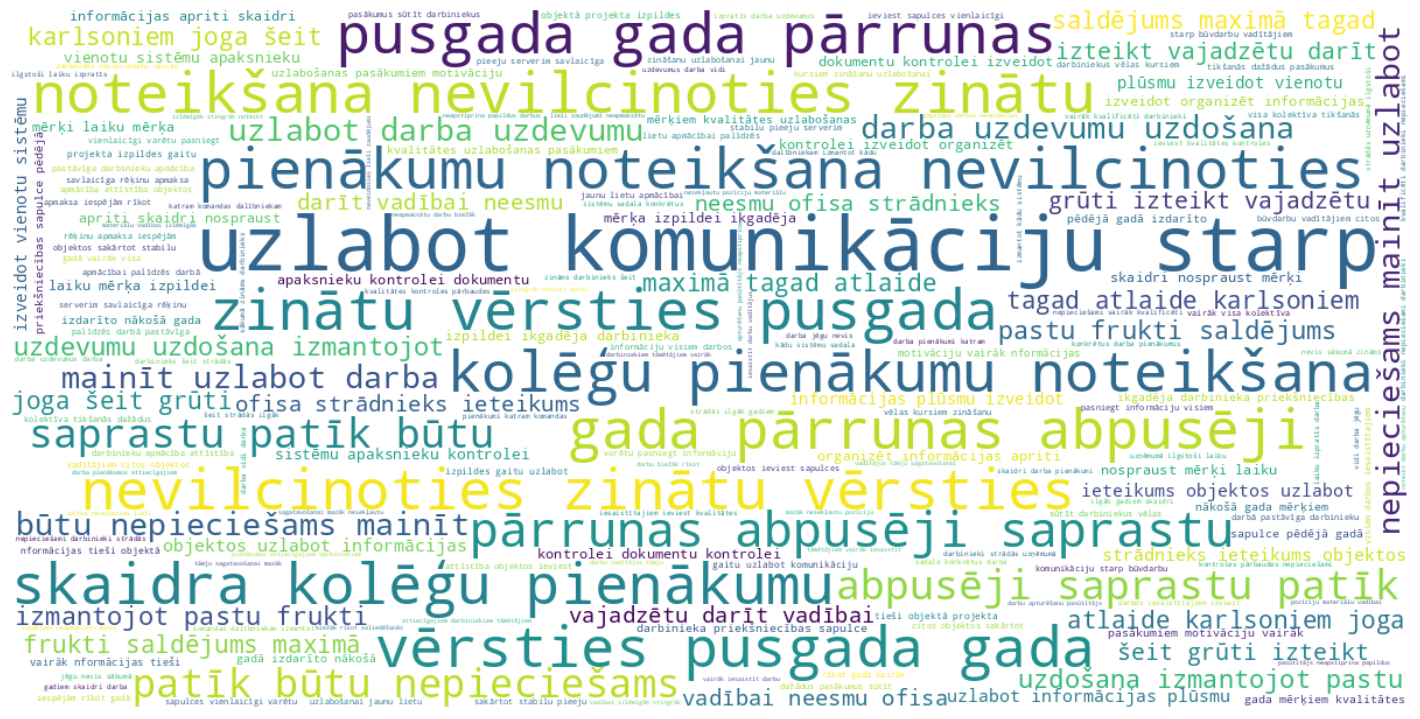

In [41]:
# Visual representation of unstructured dataset filtering by
# Recommendations for improving the organization of the work process - Trigrams
# Load data
unstructured_data = pd.read_json('/content/unstructured_data.json')

# Lower case all text in 'Ieteikumi' column
unstructured_data['Ieteikumi'] = unstructured_data['Ieteikumi'].str.lower()

# Filter out rows where 'Ieteikumi' is empty or 'No answer'
filtered_data = unstructured_data[unstructured_data['Ieteikumi'].notna() & (unstructured_data['Ieteikumi'] != 'no answer')]

import re
from wordcloud import WordCloud
from collections import Counter

# Combine all text responses from 'Ieteikumi' into a single string
text = ' '.join(filtered_data['Ieteikumi'].astype(str))

# Split the text into words and filter out words shorter than 4 characters
# Keep the word list as is for trigram creation
words = re.findall(r'\b\w+\b', text) # Find all words initially

# Filter words by length (optional, but good for reducing noise in trigrams)
min_word_length = 4
filtered_words = [word for word in words if len(word) >= min_word_length]

# Create trigrams from the filtered words
trigrams = [(filtered_words[i], filtered_words[i + 1], filtered_words[i + 2]) for i in range(len(filtered_words) - 2)]

# Join the trigram tuples into strings (e.g., "word1 word2 word3")
trigram_strings = [" ".join(trigram) for trigram in trigrams]

# Count the frequency of trigrams
trigram_counts = Counter(trigram_strings)

# Create a dictionary of trigram counts for the word cloud
# WordCloud can take a dictionary of word/phrase frequencies
trigram_freq_dict = dict(trigram_counts)

# Generate the word cloud using the trigram frequency dictionary
# You might need to adjust width/height for readability of phrases
wordcloud = WordCloud(width=1200, height=600, background_color='white').generate_from_frequencies(trigram_freq_dict)

# Display the generated image:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 7), facecolor=None) # Adjust figure size for wider trigrams
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

NameError: name 'Ieteikumi' is not defined

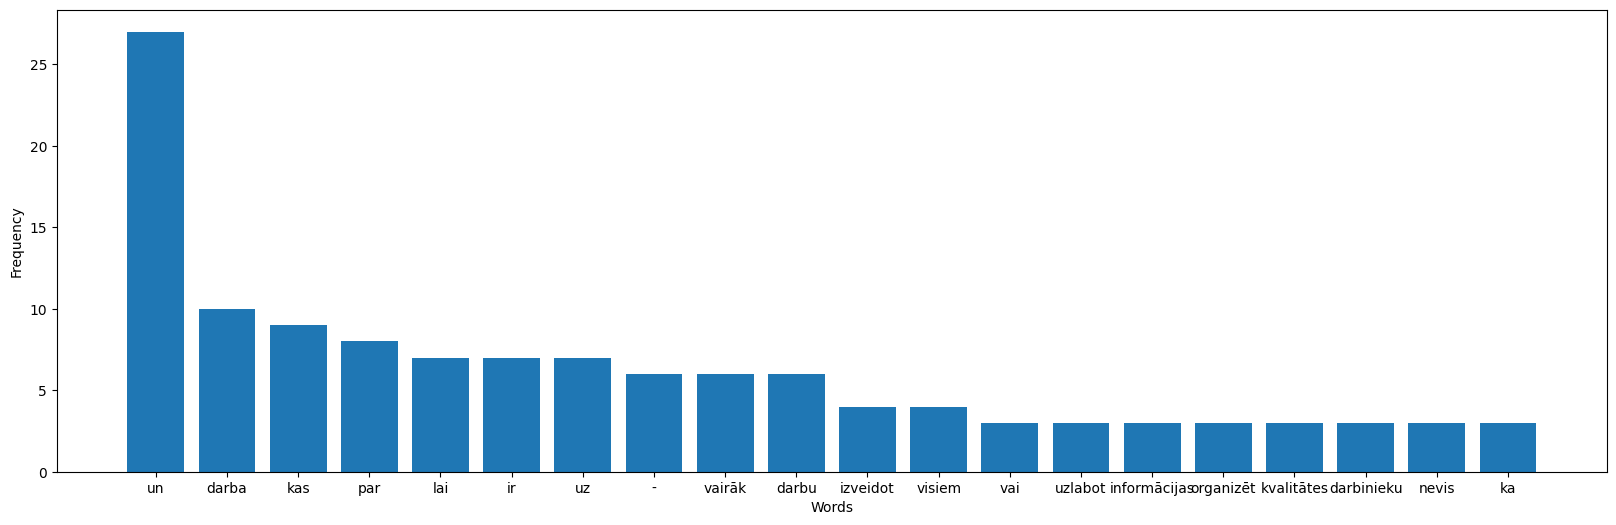

In [42]:
# Visualization: Bar plot of the most frequent words

from collections import Counter

words = text.split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)  # Show the top 20 most frequent words

words, counts = zip(*most_common_words)

plt.figure(figsize=(20, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title(f"Most frequent words in answer to question {Ieteikumi}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

See Project report added to this Google Colab Notebook.

##Conclusion

*   Ontology Framework - The developed ontology provided a structured representation of employee wellbeing data, enhancing data organization and integration. This framework improves semantic analysis, scalability, and AI system compatibility.
*   Privacy and Trust Measures - Privacy-preserving techniques like anonymization, encryption, and federated learning ensured secure and ethical data handling. These measures-built trust among stakeholders and complied with regulatory standards like GDPR.
* Machine Learning Success - Predictive models effectively identified patterns in employee well-being, demonstrating AI's potential in HR analytics. However, integrating Explainable AI (XAI) could improve model interpretability and stakeholder trust.
* Scalability and Real-World Application - AI solutions for employee wellbeing can revolutionize HR by providing actionable insights. Future work should focus on leveraging cloud technologies and advanced privacy methods to enhance scalability and adoption.


##References

1. Amazon Web Services, Inc., n.d. Define Lambda function handler in Python [WWW Document]. AWS. URL https://docs.aws.amazon.com/lambda/latest/dg/python-handler.html#python-best-practices (accessed 12.2.24).
2.	Cloud Storage Tutorial [WWW Document], n.d. . Google Cloud. URL https://cloud.google.com/functions/docs/tutorials/storage#functions-prepare-environment-python (accessed 12.2.24).
3.	Data and Beyond, n.d. . A blog on Data Science & Machine Learning for beginner. URL dataandbeyond.wordpress.com/2017/08/24/grid-search/ (accessed 12.2.24).
4.	Gabriel Suarez, 2023. ArticleAISupervisedLearning [WWW Document]. github. URL https://github.com/GabrielSB19/ArticleAISupervisedLearning (accessed 12.2.24).
5.	George, N., 2021. Practical Data Science with Python: Learn tools and techniques from hands-on examples to extract insights from data, 1st ed. Packt Publishing, Birmingham.
6.	Kelleher, J.D., Mac Namee, B., D’Arcy, A., 2020. Fundamentals of machine learning for predictive data analytics : algorithms, worked examples, and case studies., Second edition. ed. The MIT Press, Cambridge, Massachusetts.
7.	Ovh, 2020. Interpretability-engine [WWW Document]. github. URL https://github.com/ovh/interpretability-engine?tab=readme-ov-file (accessed 12.2.24).

